# Análisis Bivariante: Visualización Epidemiológica y Toxicológica de Asociaciones
### Paquete Bioestadístico HeavyStats (`heavystats.bivariate`)

Motor gráfico editorial a 300 DPI estructurado según los principios del análisis bivariante bioestadístico:
1. **Variable Cuantitativa vs. Variable Cualitativa**:
   - Contrastes no paramétricos (Mann–Whitney $U$, Kruskal–Wallis $H$, diferencias de medianas $\Delta\text{Med}$ y tamaños de efecto $r_{rb}$ / $\epsilon^2$).
   - Contrastes paramétricos (prueba $t$ de Welch, ANOVA unidireccional, diferencia de medias y Hedges' $g$ / $\eta^2$).
   - Anotación directa en corchetes (*brackets*), tamaños muestrales ($n=\dots$) en ejes y estilización de publicaciones científicas.
   - Gradientes ordinales dietarios (prueba de Jonckheere–Terpstra), mosaicos de consumo y perfiles polares (radar / spider charts).
2. **Variable Cuantitativa vs. Variable Cuantitativa**:
   - Dispersión continua, correlación de Spearman $\rho_s$ con intervalos de confianza al 95% calculados por **Bootstrap (2,000 réplicas)**, Kendall $\tau_b$ y regresión lineal OLS / Pearson $r$ ($R^2$).
   - Matrices de co-exposición bivariante: Heatmap triangular inferior estilizado y matriz de dispersión compacta con distribuciones KDE univariantes.
3. **Mosaico Bivariante Integrado y Funciones a Nivel de Módulo**:
   - Cuadrícula multipanel consolidada (`plot_grid`) y funciones funcionales de acceso directo (`compare_groups_plot`, `correlation_analysis_plot`, `diet_radar_plot`, etc.).


In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asegurar carga del módulo de desarrollo de HeavyStats
heavystats_src = Path('d:/vscode/results/HeavyStats/src')
if heavystats_src.exists() and str(heavystats_src) not in sys.path:
    sys.path.insert(0, str(heavystats_src))

import heavystats as hs
from heavystats.bivariate import (
    BivariatePlots,
    compare_groups_plot,
    correlation_analysis_plot,
    coexposure_matrix_plot,
    diet_radar_plot,
    diet_boxplots_plot,
    CDC_LEAD_REFERENCE_VALUE,
    EPA_MERCURY_REFERENCE_VALUE,
    OMS_CADMIUM_REFERENCE_VALUE
)

# Definición de rutas base y directorios de salida
base_dir = Path.cwd() if (Path.cwd() / "datos").exists() else Path.cwd().parent
ruta_datos = base_dir / "datos" / "datos_plomo.csv"

# Pipeline de preprocesamiento analítico HeavyStats
df_raw = hs.load_data(ruta_datos)
df_proc = hs.create_composite_indicators(
    hs.encode_dietary_frequencies(
        hs.desaggregate_multiple_responses(
            hs.standardize_boolean_columns(df_raw)
        )
    )
)
df_analytical = hs.select_metal(df_proc, concentration_col="plomo")

# Directorio de figuras a 300 DPI (PNG y PDF)
salidas_graficos = base_dir / "salidas" / "bivariante" / "graficos"
salidas_graficos.mkdir(parents=True, exist_ok=True)

# Instanciación del motor gráfico bivariante
bp = BivariatePlots(
    df=df_analytical,
    palette="crest",
    style="ticks",
    context="notebook"
)

print(f"Motor BivariatePlots inicializado exitosamente (N={len(df_analytical)} observaciones, {len(df_analytical.columns)} variables).")
print(f"Directorio de figuras configurado en: {salidas_graficos}")


Motor BivariatePlots inicializado exitosamente (N=20 observaciones, 58 variables).
Directorio de figuras configurado en: d:\vscode\results\HeavyStats\notebooks\salidas\bivariante\graficos


---
## 1. Variable Cuantitativa vs. Variable Cualitativa (Carga Corporal)

Evaluación de la concentración sérica del biomarcador frente a factores sociodemográficos, clínicos y ambientales.
- **Factores Dicotómicos (`plot_binary`)**: Diagrama de cajas con puntos individuales (*stripplot*), medianas [RIQ], prueba de Mann–Whitney $U$, correlación biserial de rangos ($r_{rb}$) y diferencia de medianas. Diseñado estrictamente para contraste de 2 grupos (sin línea de límite toxicológico).
- **Factores Politómicos (`plot_categorical`)**: Comparación entre >2 grupos con prueba de Kruskal–Wallis $H$ y tamaño del efecto $\epsilon^2$.
- **Contraste Paramétrico (`compare_groups(method="parametric")`)**: Medias $\pm$ DE con prueba $t$ de Welch o ANOVA unidireccional y Hedges' $g$ / $\eta^2$.


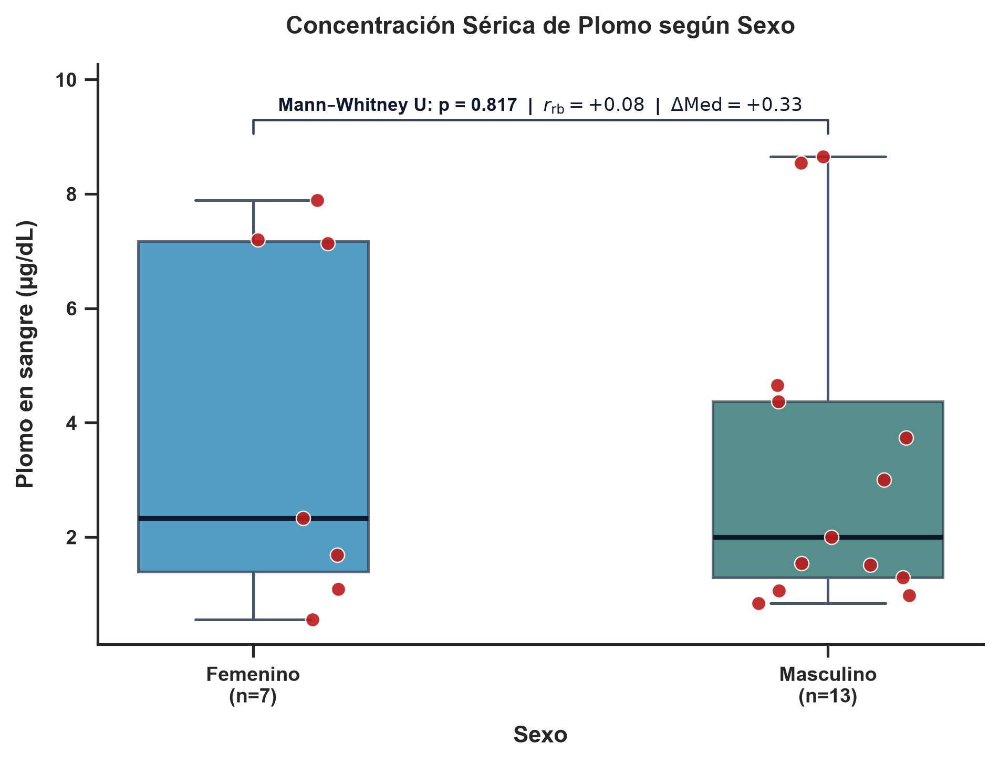

In [3]:
# 1.1 Factores Dicotómicos: Concentración de Plomo según Sexo (Femenino vs Masculino)
fig_sexo, ax_sexo = bp.plot_binary(
    metal="Plomo_ug_dL",
    group_col="Sexo",
    show_points=True,
    title="Concentración Sérica de Plomo según Sexo",
    filepath=str(salidas_graficos / "boxplot_plomo_sexo.png")
)
fig_sexo.savefig(salidas_graficos / "boxplot_plomo_sexo.pdf", dpi=300, bbox_inches="tight")
plt.show()


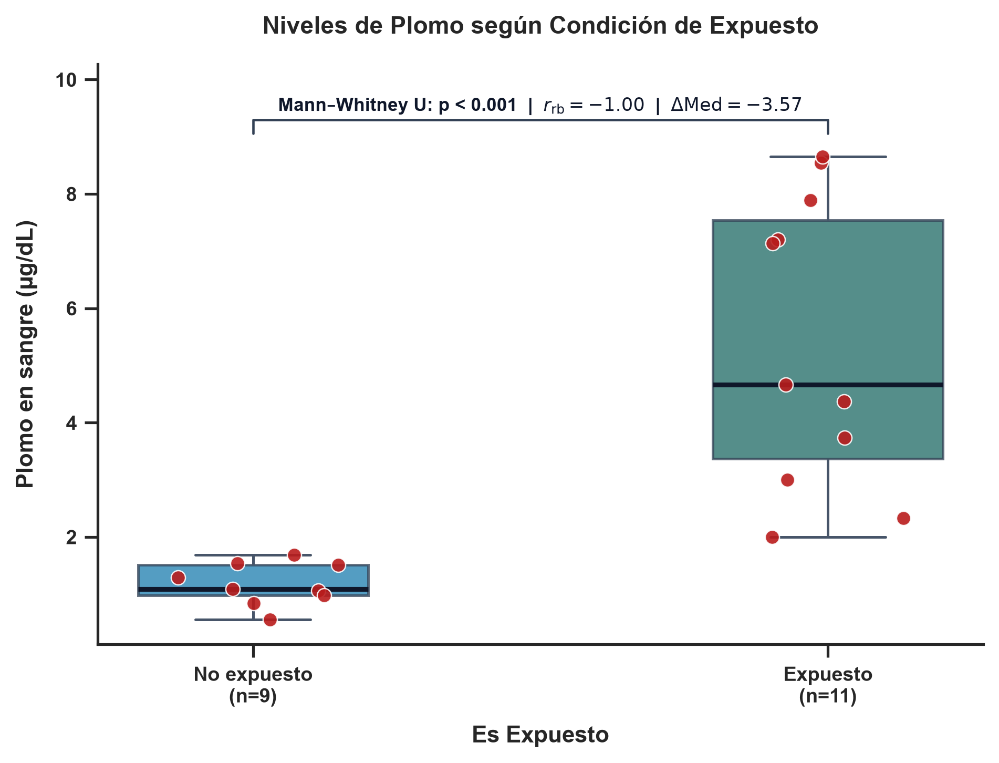

In [4]:
# 1.2 Factores Dicotómicos: Plomo según Condición de Exposición Ocupacional/Ambiental
fig_exp, ax_exp = bp.plot_binary(
    metal="Plomo_ug_dL",
    group_col="Es_Expuesto",
    show_points=True,
    title="Niveles de Plomo según Condición de Expuesto",
    filepath=str(salidas_graficos / "boxplot_plomo_es_expuesto.png")
)
fig_exp.savefig(salidas_graficos / "boxplot_plomo_es_expuesto.pdf", dpi=300, bbox_inches="tight")
plt.show()


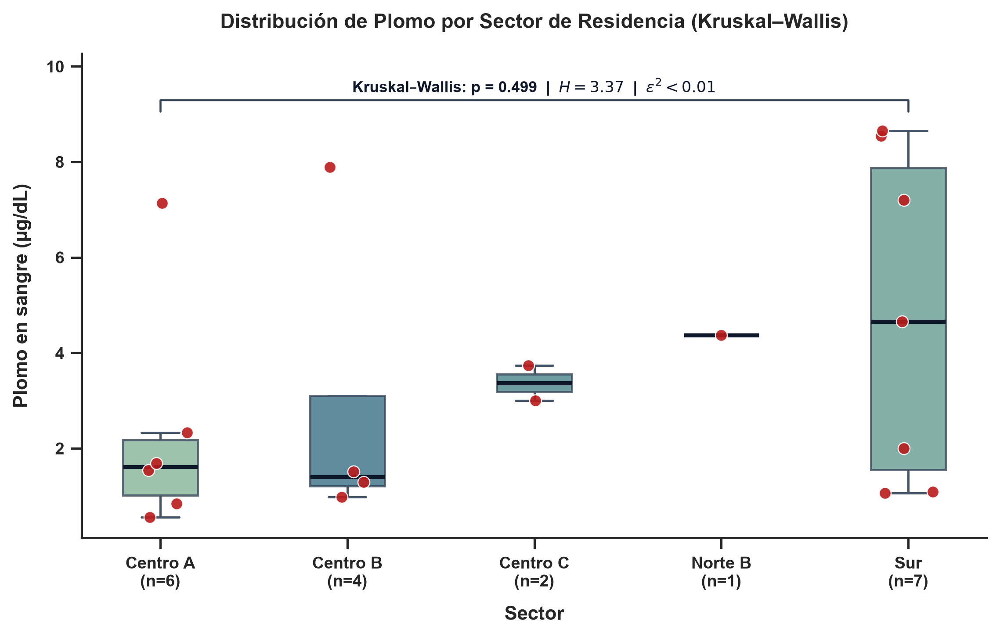

In [5]:
# 1.3 Factores Politómicos: Concentración de Plomo según Sector Geográfico (>2 grupos)
fig_sec, ax_sec = bp.plot_categorical(
    metal="Plomo_ug_dL",
    group_col="Sector",
    show_points=True,
    title="Distribución de Plomo por Sector de Residencia (Kruskal–Wallis)",
    filepath=str(salidas_graficos / "boxplot_plomo_sector.png")
)
fig_sec.savefig(salidas_graficos / "boxplot_plomo_sector.pdf", dpi=300, bbox_inches="tight")
plt.show()


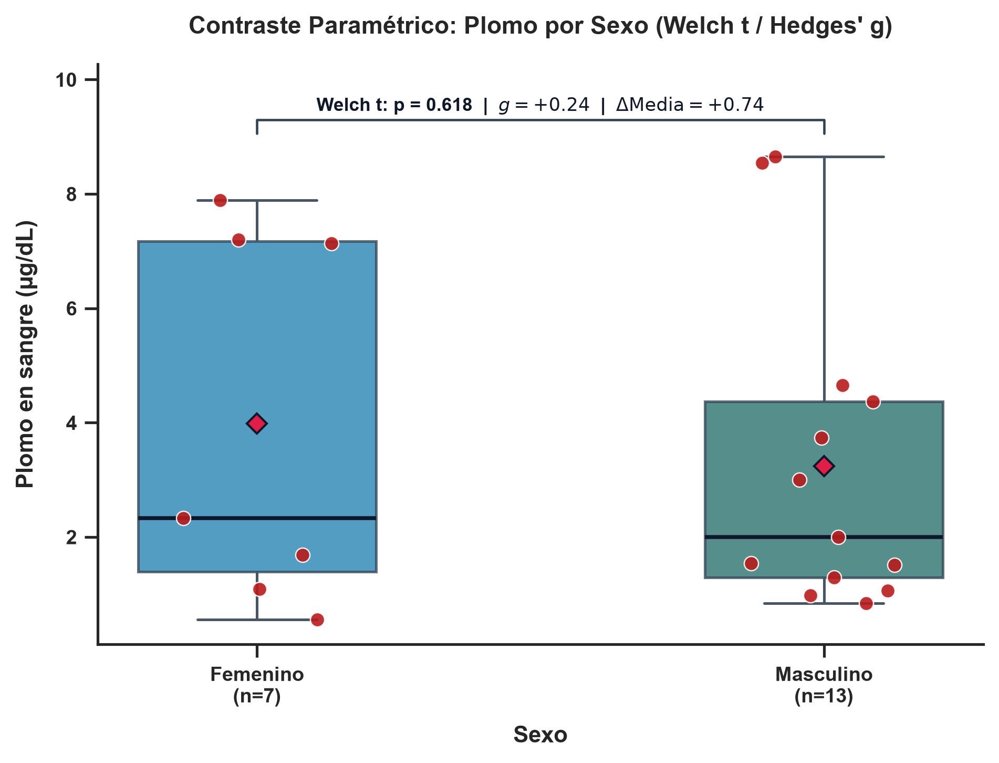

In [6]:
# 1.4 Contraste Paramétrico: Prueba t de Welch con Media ± DE y Tamaño de Efecto Hedges' g
fig_param, ax_param = bp.compare_groups(
    quantitative="Plomo_ug_dL",
    group="Sexo",
    method="parametric",
    show_points=True,
    title="Contraste Paramétrico: Plomo por Sexo (Welch t / Hedges' g)",
    filepath=str(salidas_graficos / "boxplot_plomo_sexo_parametrico.png")
)
fig_param.savefig(salidas_graficos / "boxplot_plomo_sexo_parametrico.pdf", dpi=300, bbox_inches="tight")
plt.show()


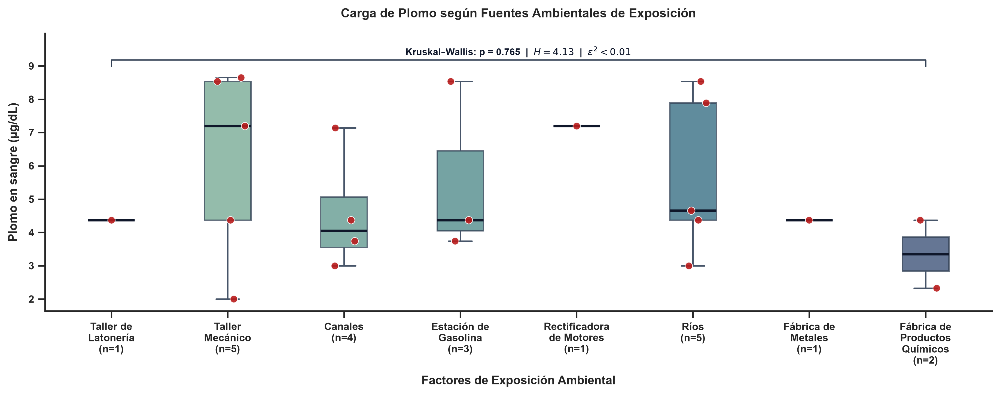

In [7]:
# 1.5 Factores de Exposición por Variables Dummy de Proximidad Ambiental
fig_dummies, ax_dummies = bp.plot_dummies(
    metal="Plomo_ug_dL",
    dimension="all",
    show_points=True,
    title="Carga de Plomo según Fuentes Ambientales de Exposición",
    filepath=str(salidas_graficos / "boxplot_plomo_factores_ambientales.png")
)
fig_dummies.savefig(salidas_graficos / "boxplot_plomo_factores_ambientales.pdf", dpi=300, bbox_inches="tight")
plt.show()


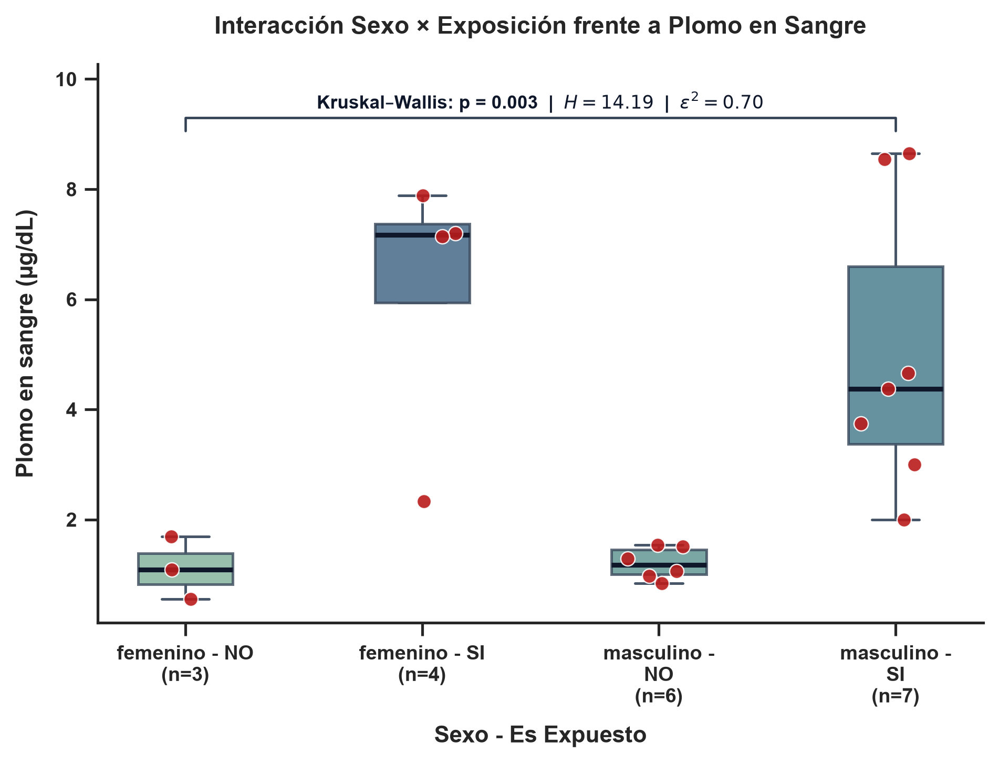

In [8]:
# 1.6 Interacción de Factores: Estratificación Cruzada [Sexo - Condición de Expuesto]
fig_inter, ax_inter = bp.compare_groups(
    quantitative="Plomo_ug_dL",
    group=["Sexo", "Es_Expuesto"],
    show_points=True,
    title="Interacción Sexo × Exposición frente a Plomo en Sangre",
    filepath=str(salidas_graficos / "boxplot_plomo_interaccion_sexo_expuesto.png")
)
fig_inter.savefig(salidas_graficos / "boxplot_plomo_interaccion_sexo_expuesto.pdf", dpi=300, bbox_inches="tight")
plt.show()


---
## 2. Hábitos Dietarios y Validación del Algoritmo de Riesgo

- **Gradiente Dosis–Respuesta**: Análisis de tendencia ordinal (no paramétrico con Jonckheere–Terpstra o paramétrico con Pearson).
- **Mosaicos Dietarios**: Formato facetado en cuadrícula (`layout='grid'`), con contrastes estadísticos seleccionables (paramétrico/no paramétrico).
- **Perfil Multivariante Polar (Radar / Spider Chart)**: Comparación de patrones alimentarios mediante `ax.set_thetagrids()` estratificada por mediana o terciles de concentración.
- **Validación del Score de Riesgo**: Regresión empírica frente al biomarcador biológico con bandas de confianza al 95%.


In [ ]:
# 2.1 Tendencia Ordinal: Frecuencia de Consumo de Carnes vs Plomo
metodo_dieta = "nonparametric"  # o "parametric"

fig_carnes, ax_carnes = bp.plot_dietary(
    ordinal_col="Alim_Carnes",
    metal="Plomo_ug_dL",
    method=metodo_dieta,
    show_points=True,
    filepath=str(salidas_graficos / "tendencia_ordinal_plomo_carnes.png")
)
fig_carnes.savefig(salidas_graficos / "tendencia_ordinal_plomo_carnes.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# 2.2 Mosaico Dietario Multivariable Facetado: Todos los Grupos de Alimentos vs Plomo
fig_diet_grid, axes_diet_grid = bp.plot_diet_boxplots(
    metal="Plomo_ug_dL",
    method=metodo_dieta,
    layout="grid",
    ncols=4,
    filepath=str(salidas_graficos / "mosaico_dietario_grid_plomo.png")
)
fig_diet_grid.savefig(salidas_graficos / "mosaico_dietario_grid_plomo.pdf", dpi=300, bbox_inches="tight")
plt.show()


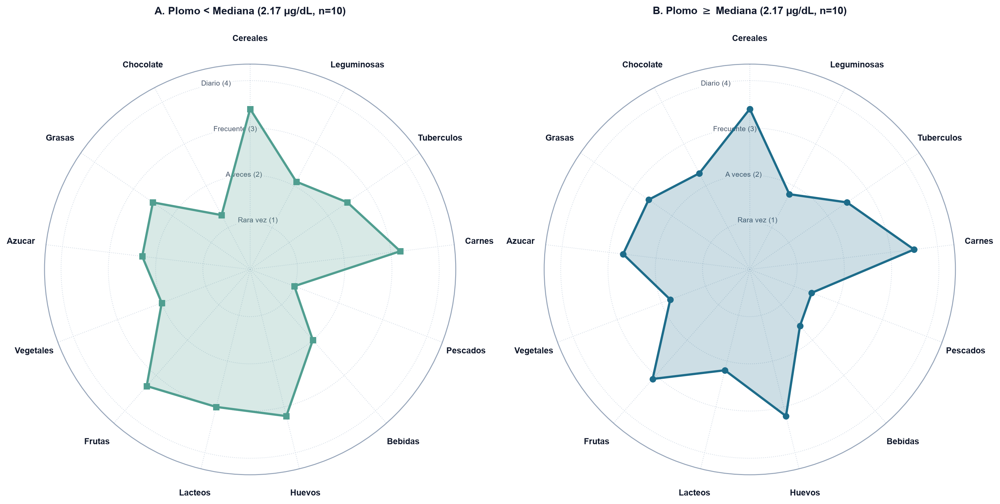

In [12]:
# 2.3 Perfil Dietario en Coordenadas Polares (Radar Chart) Estratificado por Mediana
fig_radar, axes_radar = bp.plot_diet_radar(
    metal="Plomo_ug_dL",
    stratify_by="median",
    split_panels=True,
    figsize=(15.0, 7.5),
    filepath=str(salidas_graficos / "radar_dietario_plomo_split.png")
)
fig_radar.savefig(salidas_graficos / "radar_dietario_plomo_split.pdf", dpi=300, bbox_inches="tight")
plt.show()


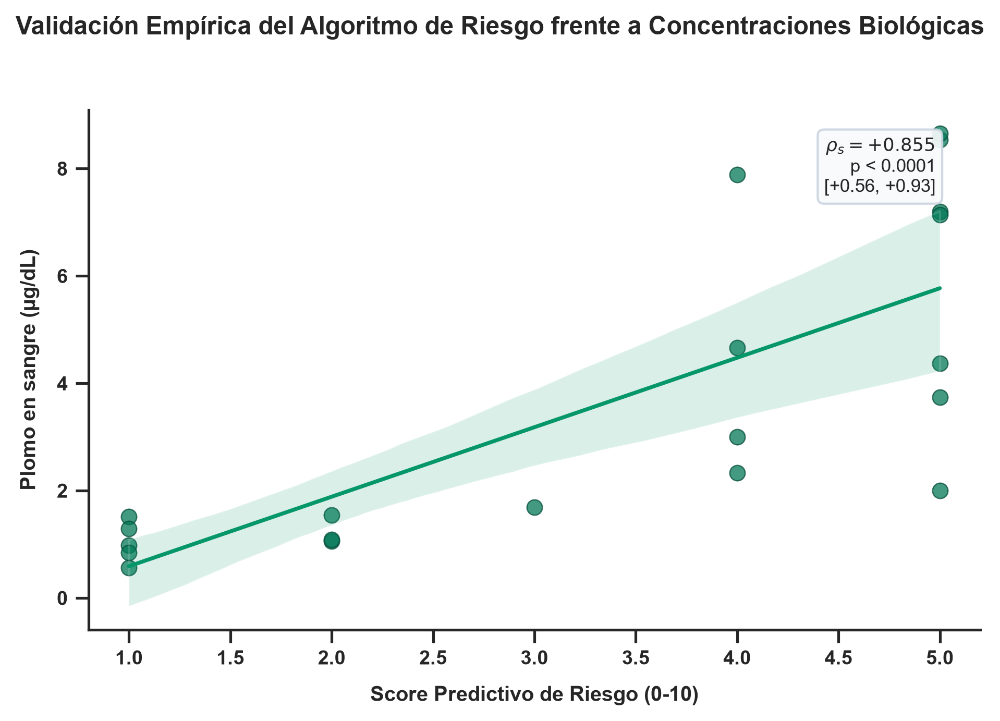

In [13]:
# 2.5 Validación Empírica del Algoritmo de Riesgo frente a Concentraciones Biológicas
fig_risk, axes_risk = bp.plot_risk_algorithm(
    metals=["Plomo_ug_dL"],
    figsize=(6.5, 4.5),
    filepath=str(salidas_graficos / "validacion_algoritmo_riesgo_plomo.png")
)
fig_risk.savefig(salidas_graficos / "validacion_algoritmo_riesgo_plomo.pdf", dpi=300, bbox_inches="tight")
plt.show()


---
## 3. Variable Cuantitativa vs. Variable Cuantitativa (Gradientes Continuos y Co-Exposición)

- **Correlación Continua Bivariante**: Ajuste de regresión lineal con banda de confianza al 95%, coeficiente de Spearman $\rho_s$ con IC 95% Bootstrap (2,000 remuestreos) y Kendall $\tau_b$.
- **Matriz de Co-Exposición Bivariante**:
  - `kind="heatmap"`: Matriz triangular inferior con paleta divergente, coeficientes e intervalos Bootstrap.
  - `kind="scatter"`: Matriz compacta de dispersión bivariante con densidades KDE univariantes en la diagonal y resúmenes estadísticos en el triángulo superior.


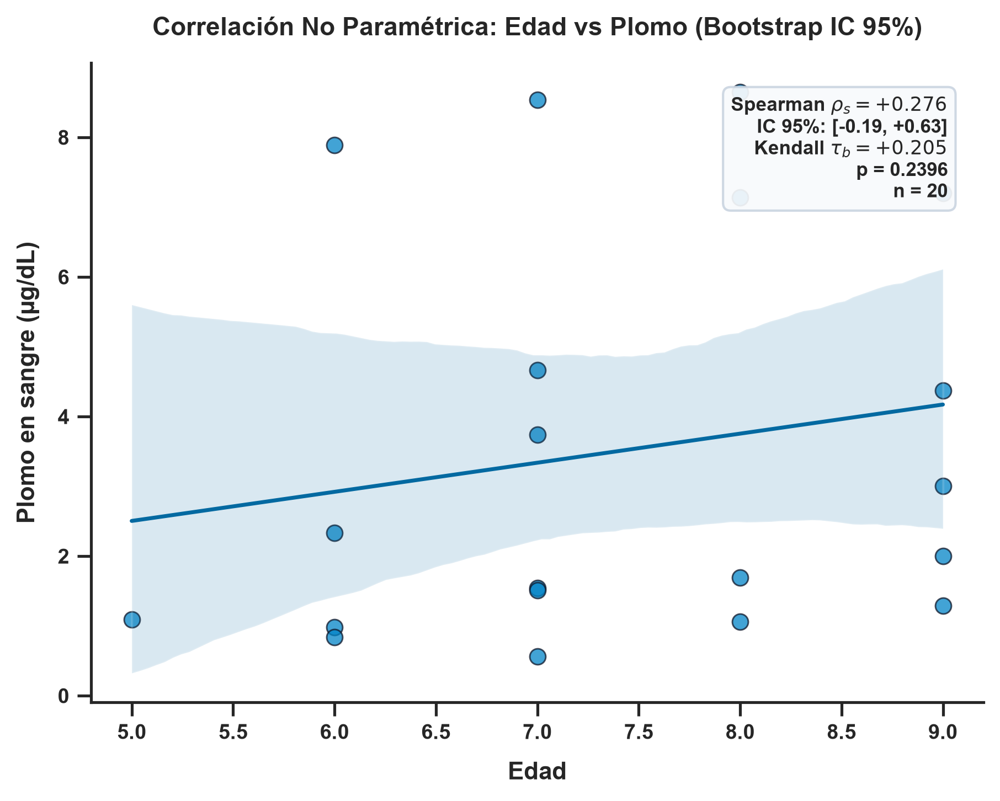

In [14]:
# 3.1 Dispersión y Correlación No Paramétrica: Edad vs Concentración de Plomo
fig_corr_sp, ax_corr_sp = bp.correlation_analysis(
    x="Edad",
    y="Plomo_ug_dL",
    method="nonparametric",
    n_boot=2000,
    title="Correlación No Paramétrica: Edad vs Plomo (Bootstrap IC 95%)",
    filepath=str(salidas_graficos / "dispersion_plomo_edad_spearman.png")
)
fig_corr_sp.savefig(salidas_graficos / "dispersion_plomo_edad_spearman.pdf", dpi=300, bbox_inches="tight")
plt.show()


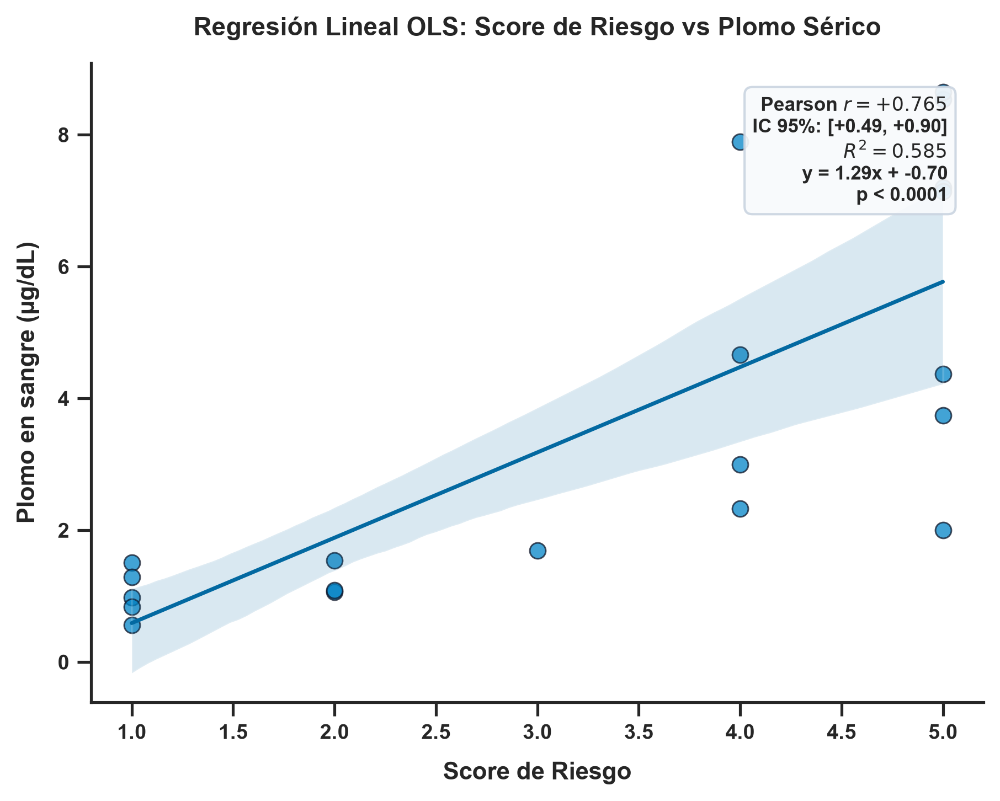

In [15]:
# 3.2 Regresión Paramétrica: Score de Riesgo vs Plomo (Pearson r, Ecuación OLS y R²)
fig_corr_pr, ax_corr_pr = bp.correlation_analysis(
    x="Score_Riesgo",
    y="Plomo_ug_dL",
    method="parametric",
    title="Regresión Lineal OLS: Score de Riesgo vs Plomo Sérico",
    filepath=str(salidas_graficos / "regresion_plomo_score_riesgo_pearson.png")
)
fig_corr_pr.savefig(salidas_graficos / "regresion_plomo_score_riesgo_pearson.pdf", dpi=300, bbox_inches="tight")
plt.show()


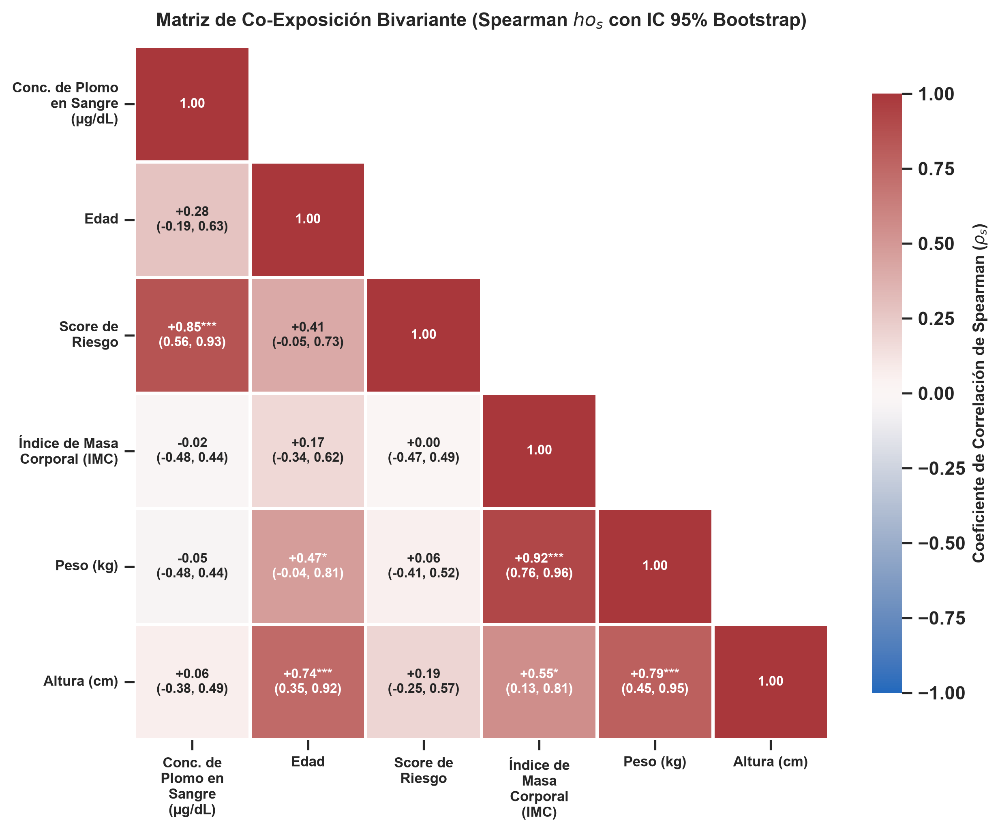

In [16]:
# 3.3 Matriz de Co-Exposición Cuantitativa: Heatmap Triangular Editorial
cols_cuant = [c for c in ["Plomo_ug_dL", "Edad", "Score_Riesgo", "IMC", "Peso_kg", "Altura_cm"] if c in df_analytical.columns]

fig_coexp_heat, ax_coexp_heat = bp.plot_coexposure_matrix(
    variables=cols_cuant,
    kind="heatmap",
    method="nonparametric",
    n_boot=2000,
    title=r"Matriz de Co-Exposición Bivariante (Spearman $ho_s$ con IC 95% Bootstrap)",
    filepath=str(salidas_graficos / "matriz_coexposicion_heatmap.png")
)
fig_coexp_heat.savefig(salidas_graficos / "matriz_coexposicion_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()


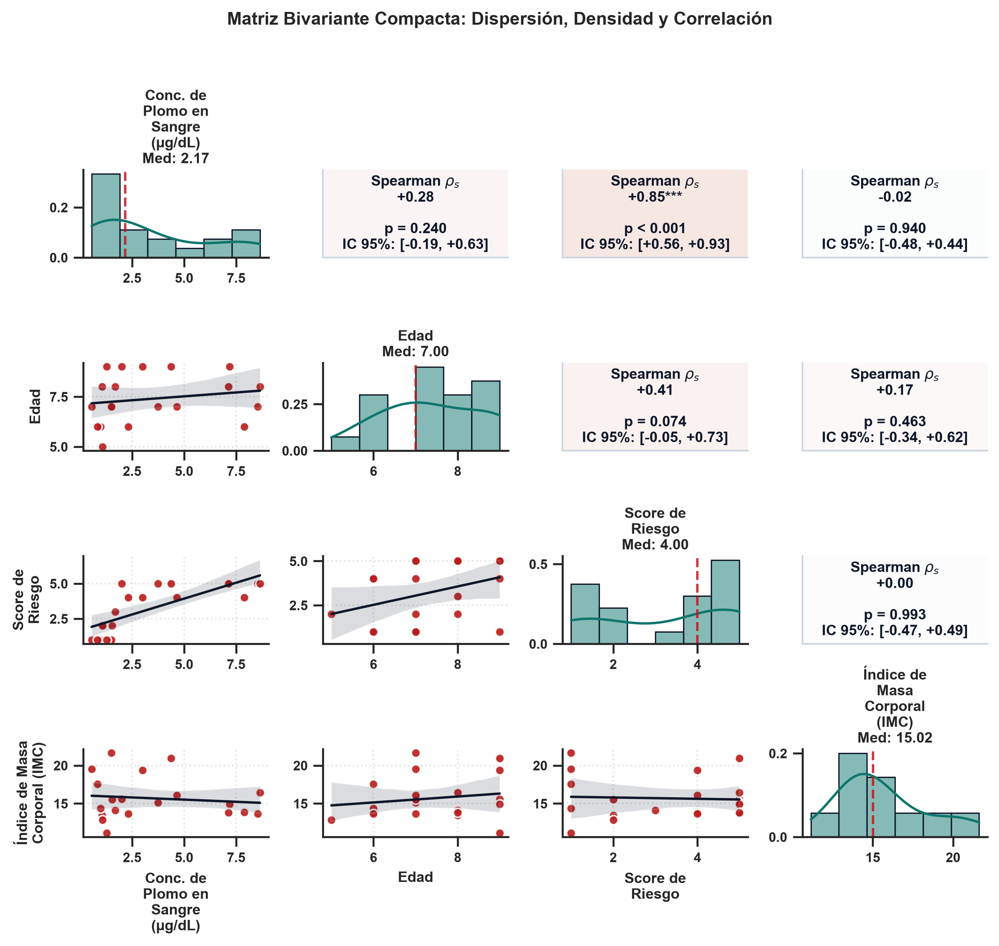

In [17]:
# 3.4 Matriz de Dispersión y Co-Exposición Compacta (Scatter + KDE + Estadísticos)
core_cuant = [c for c in ["Plomo_ug_dL", "Edad", "Score_Riesgo", "IMC"] if c in df_analytical.columns]

fig_coexp_scat, axes_coexp_scat = bp.plot_coexposure_matrix(
    variables=core_cuant,
    kind="scatter",
    method="nonparametric",
    n_boot=2000,
    title="Matriz Bivariante Compacta: Dispersión, Densidad y Correlación",
    filepath=str(salidas_graficos / "matriz_coexposicion_dispersion_compacta.png")
)
fig_coexp_scat.savefig(salidas_graficos / "matriz_coexposicion_dispersion_compacta.pdf", dpi=300, bbox_inches="tight")
plt.show()


---
## 4. Mosaico Bivariante Integrado y Funciones a Nivel de Módulo

- **Cuadrícula Exploratoria Multideterminante (`plot_grid`)**: Agrupa en un único lienzo factores binarios, politómicos, continuos y ordinales.
- **Funciones de Conveniencia a Nivel de Módulo**: Acceso funcional directo sin necesidad de instanciar `BivariatePlots` (ideal para scripts analíticos y pipelines automatizados).


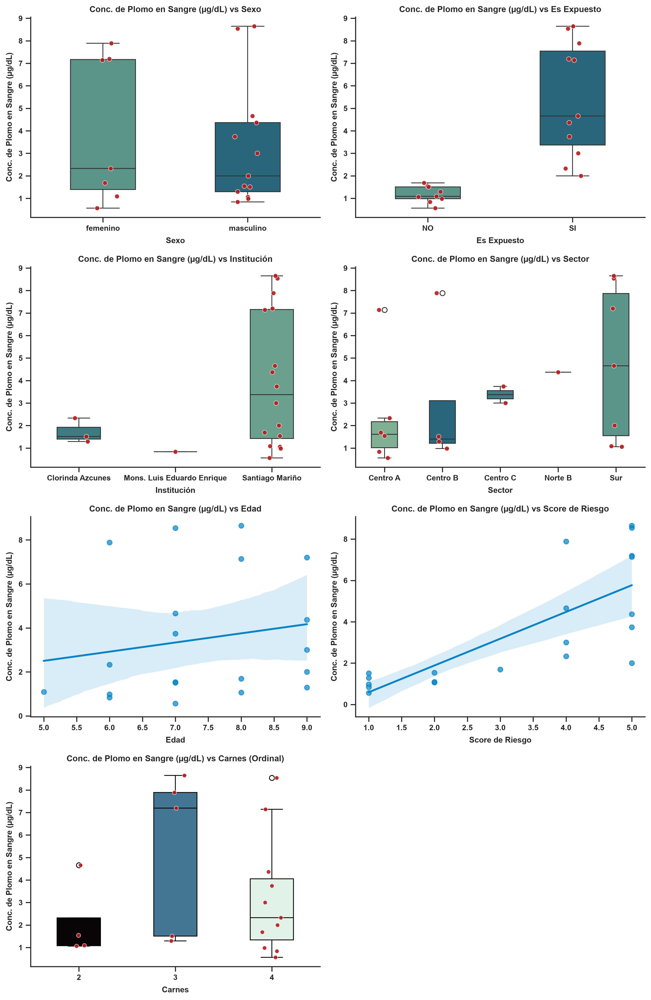

In [18]:
# 4.1 Mosaico Bivariante Integrado: Factores Sociodemográficos, Clínicos y Ambientales
fig_grid, axes_grid = bp.plot_grid(
    metal="Plomo_ug_dL",
    binary_cols=["Sexo", "Es_Expuesto"],
    categorical_cols=["Institucion", "Sector"],
    continuous_cols=["Edad", "Score_Riesgo"],
    ordinal_cols=["Alim_Carnes"],
    ncols=2,
    filepath=str(salidas_graficos / "mosaico_editorial_bivariante_plomo.png")
)
fig_grid.savefig(salidas_graficos / "mosaico_editorial_bivariante_plomo.pdf", dpi=300, bbox_inches="tight")
plt.show()


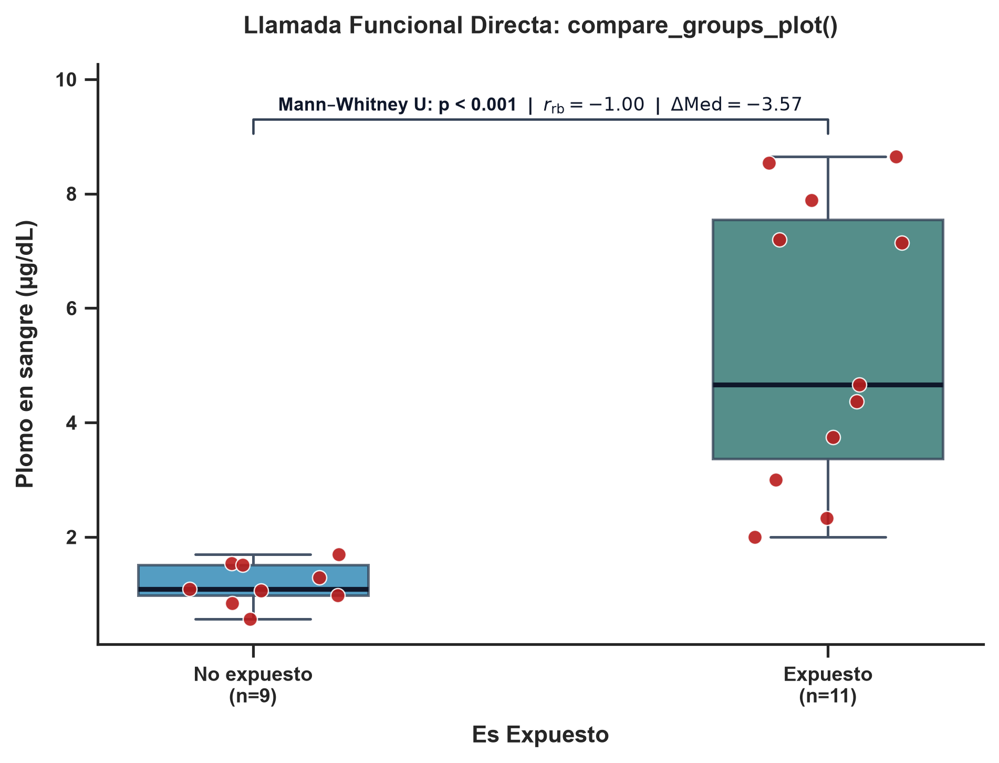

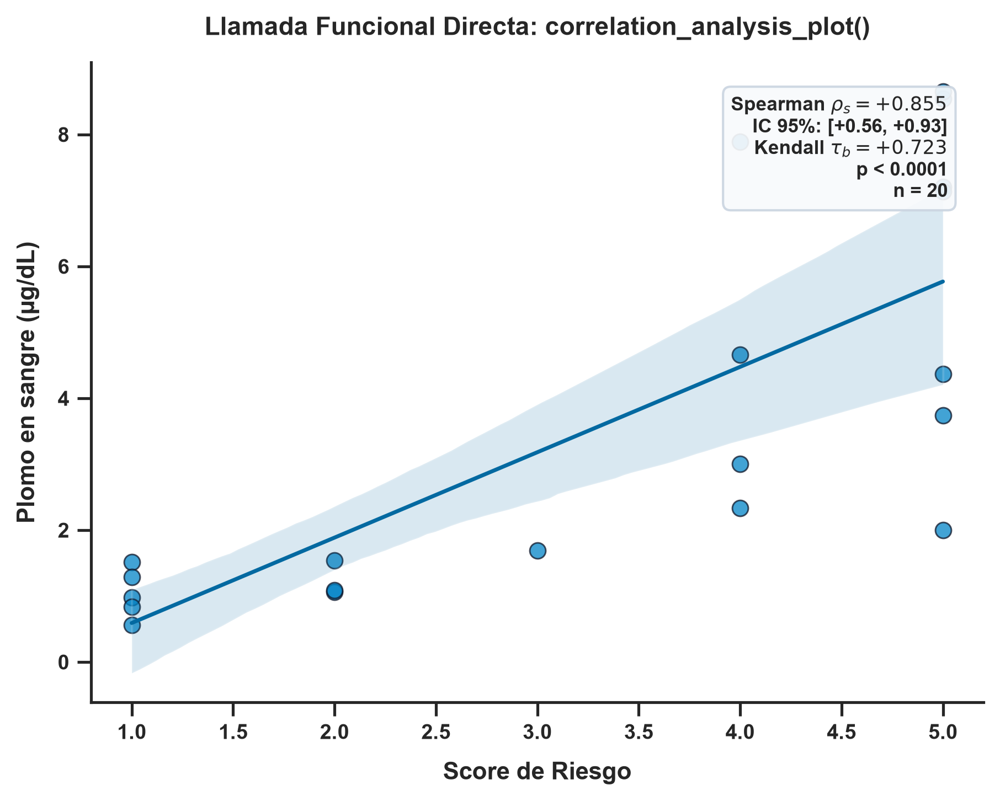


¡Cuaderno bivariante ejecutado exitosamente con todas las funciones del paquete!
Todas las figuras exportadas a 300 DPI en formato PNG y PDF en:
  -> D:\vscode\results\HeavyStats\notebooks\salidas\bivariante\graficos


In [19]:
# 4.2 Uso de Funciones Funcionales Directas del Módulo (API Funcional sin Instanciación)
# Ejemplo con compare_groups_plot()
fig_fn_comp, ax_fn_comp = compare_groups_plot(
    df=df_analytical,
    quantitative="Plomo_ug_dL",
    group="Es_Expuesto",
    title="Llamada Funcional Directa: compare_groups_plot()"
)
plt.show()

# Ejemplo con correlation_analysis_plot()
fig_fn_corr, ax_fn_corr = correlation_analysis_plot(
    df=df_analytical,
    x="Score_Riesgo",
    y="Plomo_ug_dL",
    title="Llamada Funcional Directa: correlation_analysis_plot()"
)
plt.show()

print(f"\n¡Cuaderno bivariante ejecutado exitosamente con todas las funciones del paquete!")
print(f"Todas las figuras exportadas a 300 DPI en formato PNG y PDF en:\n  -> {salidas_graficos.resolve()}")


In [20]:
import heavystats as hs
from heavystats.bivariate import (
    BivariatePlots,
    compare_groups_plot,
    correlation_analysis_plot,
    coexposure_matrix_plot,
    diet_radar_plot,
    diet_boxplots_plot,
    similarity_ranking_plot,
    subcohort_contrast_plot,
    shared_factors_plot,
    subcohort_mosaic_plot,
    survey_block_heatmap_plot,
    survey_radiography_plot,
)

bp = BivariatePlots(
    df=df_analytical, palette="crest", style="ticks", context="notebook"
)


In [21]:
df_analytical.iloc[12]

Muestra_Codificada                                                             13
Edad                                                                            6
Sexo                                                                     femenino
Peso_kg                                                                      19.0
Altura_cm                                                                   118.0
Sector                                                                   Centro A
Institucion                                                      Clorinda Azcunes
Es_Expuesto                                                                    SI
Riesgo_Pb                                                                      NO
Score_Riesgo                                                                    4
Plomo_ug_dL                                                                  2.33
Exposicion_Talleres                                     Ninguna de las anteriores
Exposicion_Indus

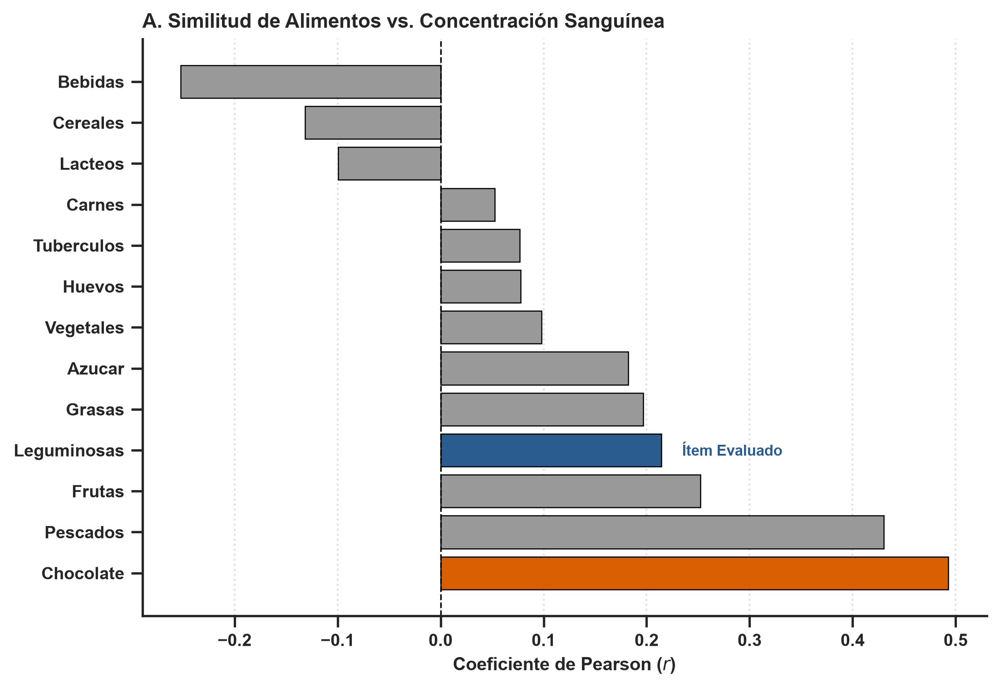

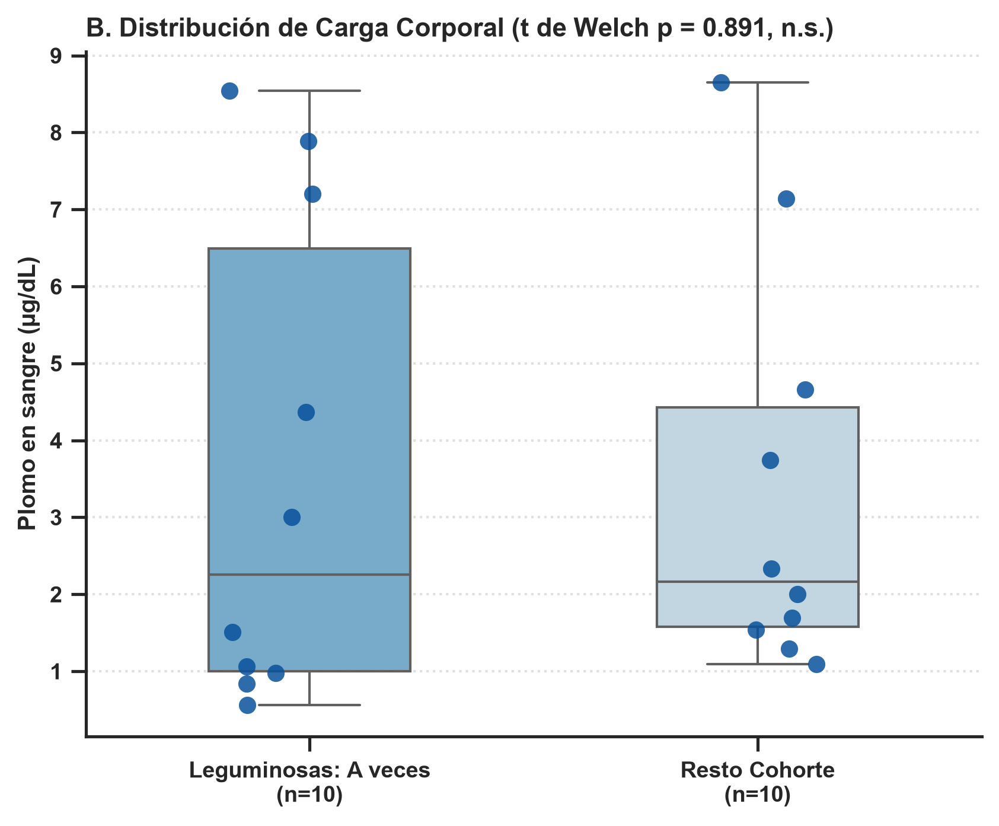

In [22]:
# ==============================================================================
# ANÁLISIS DE SIMILITUD DIETARIA Y CONTRASTE TOXICOLÓGICO DE SUBCOHORTE
# (Gráficos modulares individuales mediante BivariatePlots de HeavyStats)
# ==============================================================================
import matplotlib.pyplot as plt

# Selección del método analítico: 'nonparametric' (Spearman / Mann-Whitney) o 'parametric' (Pearson / t de Welch)
metodo_analisis = "parametric"  # Cambiar a 'parametric' si se desea inferencia paramétrica

# --- 1. Gráficos Modulares Individuales (Listos para componer en cualquier grid) ---
# Panel A: Ranking de Asociación de Alimentos vs Carga Corporal Metálica
fig_a, ax_a, df_similitud = bp.similarity_ranking_plot(
    target_metal="Plomo_ug_dL                                                                  ",
    highlight_item="Alim_Leguminosas",
    method=metodo_analisis,
    title="A. Similitud de Alimentos vs. Concentración Sanguínea",
)
plt.show()

# Panel B: Contraste Toxicológico de la Opción de Mayor Frecuencia/Consumo vs Resto de la Muestra
# (Al omitir criterion_val, se detecta y contrasta automáticamente la categoría modal con mayor cantidad de muestras)
fig_b, ax_b, stats_b = bp.subcohort_contrast_plot(
    target_metal="Plomo_ug_dL                                                                  ",
    criterion_col="Alim_Leguminosas",
    criterion_val=None,         # Auto-selección: categoría modal con mayor tamaño muestral
    method=metodo_analisis,     # Método paramétrico o no paramétrico
    annotate_ids=False,         # Sin marcado de IDs individuales
)
plt.show()


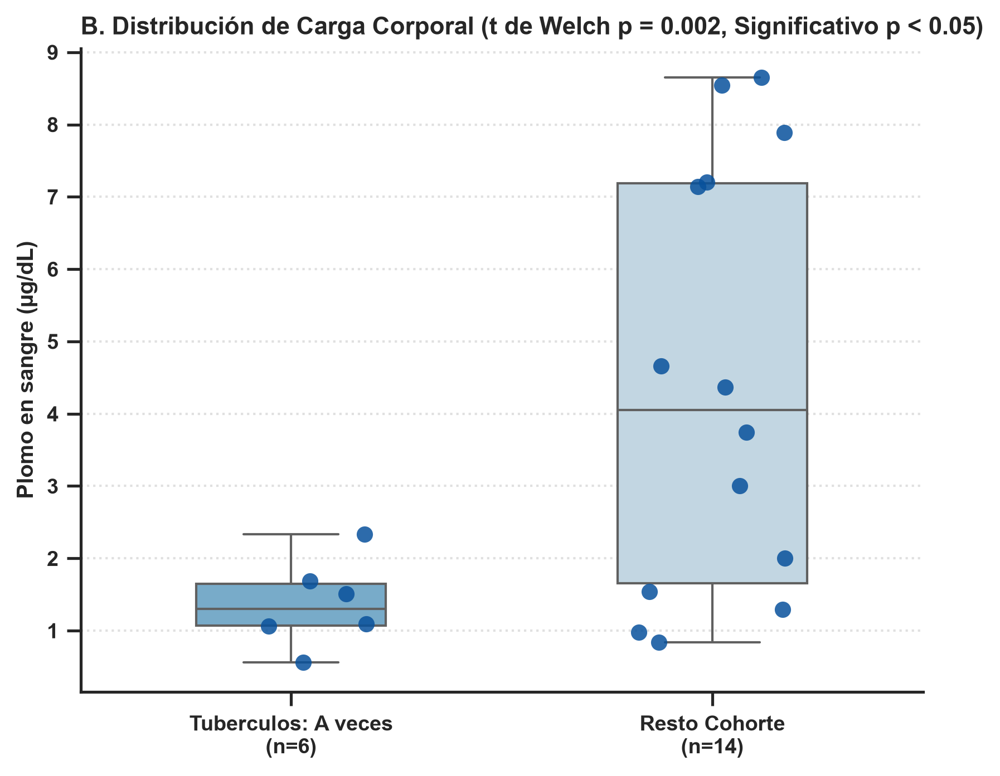

,Nombre,Categoria,Tipo,N_Sub,N_Rest,p_valor,Significativo
0,Tuberculos,A veces,Moda vs Resto,6,14,0.002157,True
1,Chocolate,Rara vez,Moda vs Resto,6,14,0.054022,False
2,Pescados,Nunca,Moda vs Resto,7,13,0.056213,False
3,Frutas,Diario,Moda vs Resto,11,9,0.480573,False
4,Carnes,Diario,Moda vs Resto,11,9,0.619001,False
5,Cereales,Diario,Moda vs Resto,10,10,0.634757,False
6,Vegetales,A veces,Moda vs Resto,7,13,0.659028,False
7,Lacteos,Diario,Moda vs Resto,6,14,0.757177,False
8,Bebidas,Rara vez,Moda vs Resto,7,13,0.787874,False
9,Grasas,Frecuente,Moda vs Resto,8,12,0.821824,False


In [23]:
# ==============================================================================
# ESCANEO AUTOMATIZADO DE CONTRASTES TOXICOLÓGICOS SIGNIFICATIVOS (p < 0.05)
# ==============================================================================
metodo_analisis = "parametric"  # o "nonparametric"

# 1. Escaneo de opciones modales (categoría de mayor frecuencia vs resto)
#    plot_significant=True renderiza el gráfico solo si p < 0.05
df_ranking_subcohortes = bp.scan_subcohort_contrasts(
    target_metal="Plomo_ug_dL",
    candidate_cols=[c for c in df_analytical.columns if c.startswith("Alim_")],
    method=metodo_analisis,
    alpha=0.05,
    test_all_categories=False,  # True si deseas evaluar todas las opciones de consumo
    plot_significant=True,      # Muestra el gráfico de las variables significativas
)

# Visualizar la tabla de resultados clasificada por p-valor
df_ranking_subcohortes[["Nombre", "Categoria", "Tipo", "N_Sub", "N_Rest", "p_valor", "Significativo"]]


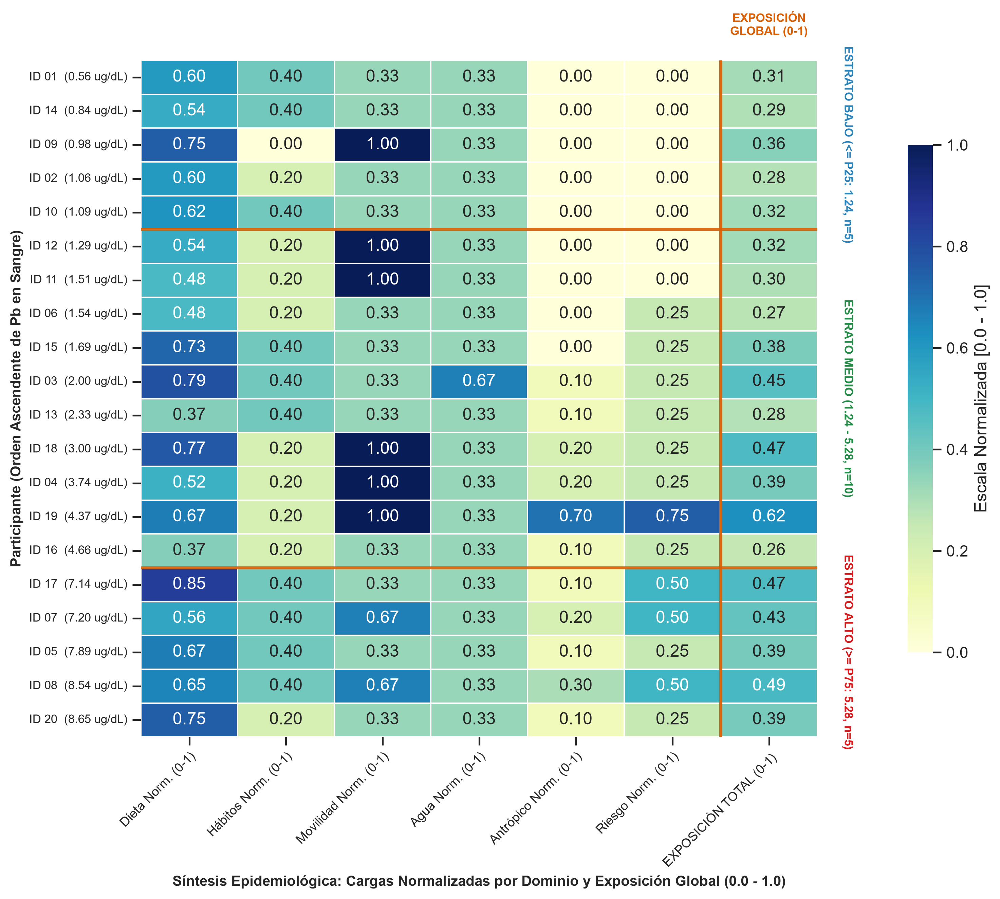


[OK] Matriz de síntesis epidemiológica generada exitosamente en:
  -> D:\vscode\results\HeavyStats\notebooks\salidas\bivariante\graficos


In [ ]:
# ==============================================================================
# RADIOGRAFÍA EPIDEMIOLÓGICA DESAGREGADA (N=20) EN MAPAS DE CALOR TEMÁTICOS
# (Integrado en el Motor Bioestadístico BivariatePlots de HeavyStats)
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Matriz de Síntesis Epidemiológica Global (Cargas por Dominio y Exposición Global)
#    (Genera la matriz editorial estratificada por percentiles P25 y P75)
fig_sintesis, ax_sintesis = bp.plot_survey_synthesis(
    target_metal="Plomo_ug_dL",
    id_col="Muestra_Codificada",
    p25_quantile=0.25,
    p75_quantile=0.75,
    output_dir=salidas_graficos,
    show=True,
    dpi=300,
)


print(
    f"\n[OK] Matriz de síntesis epidemiológica generada exitosamente en:"
    f"\n  -> {salidas_graficos.resolve()}"
)


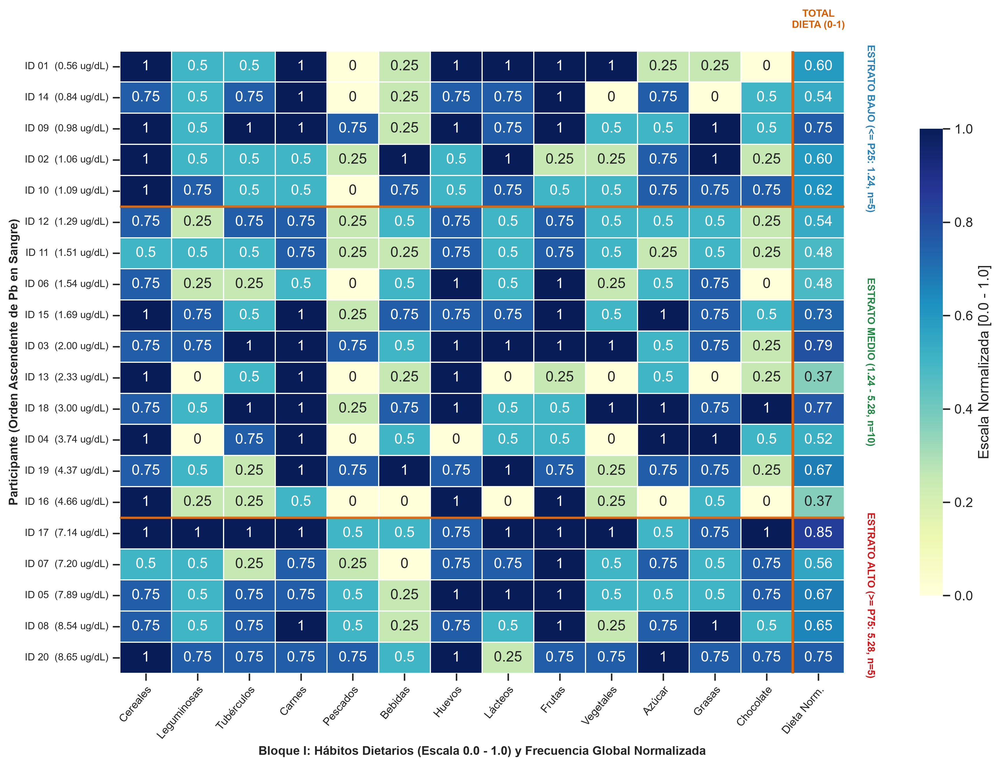

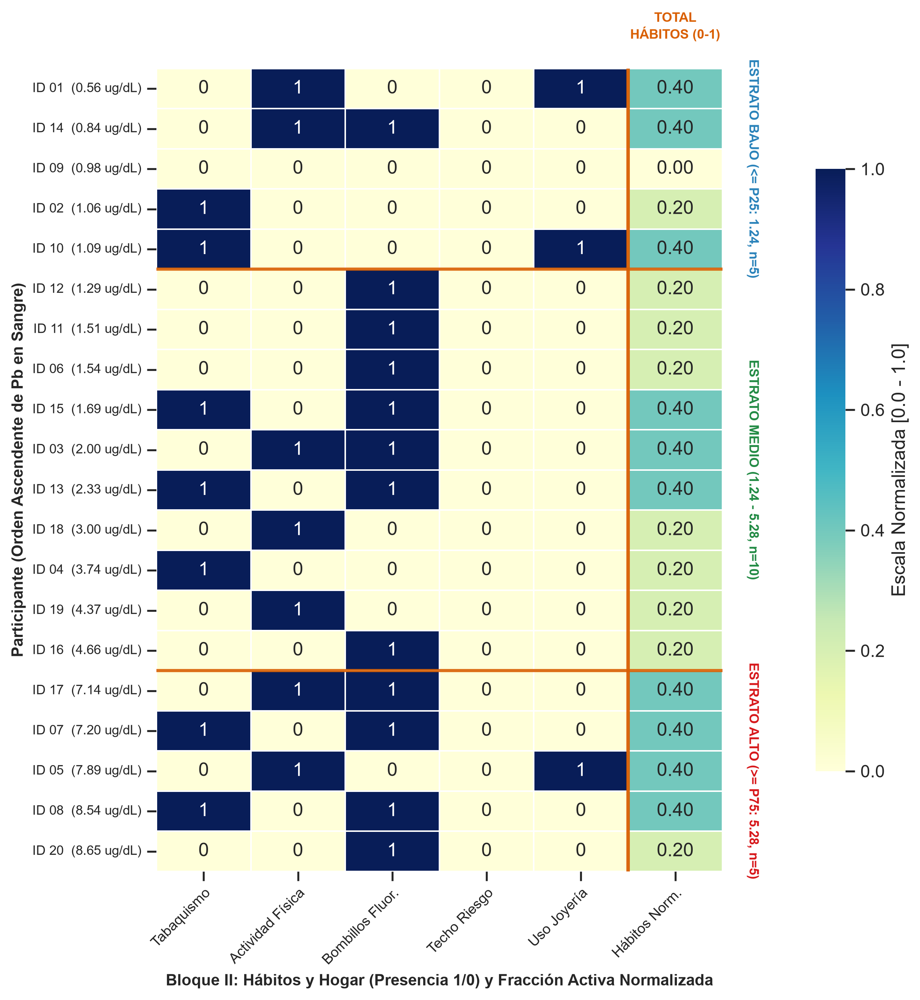

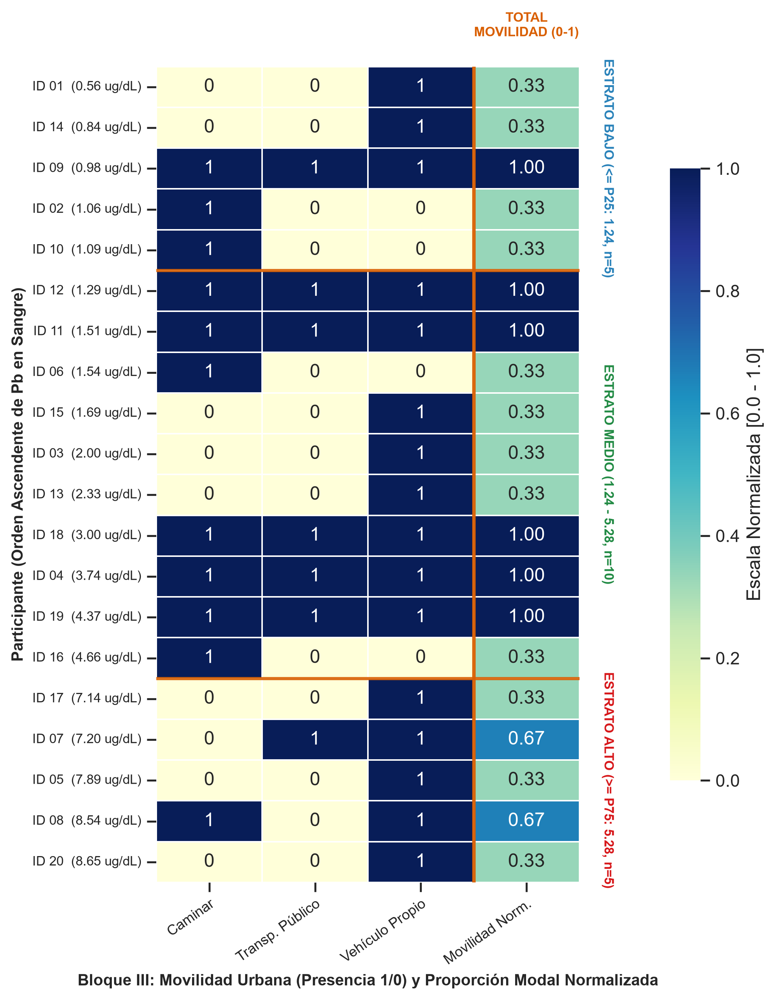

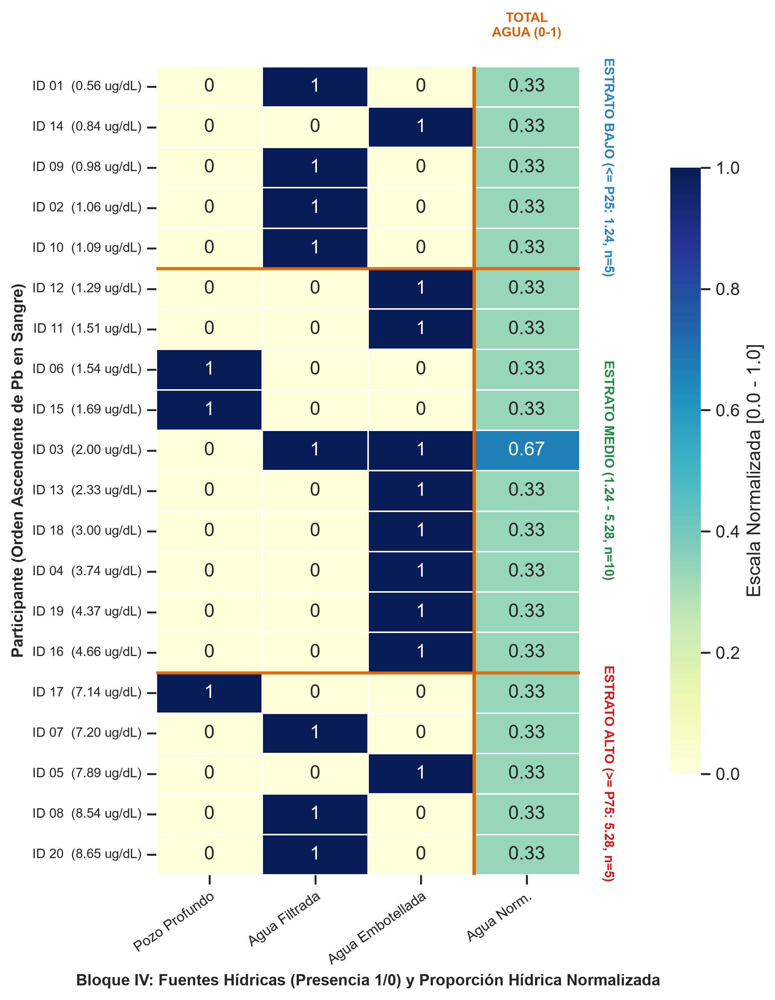

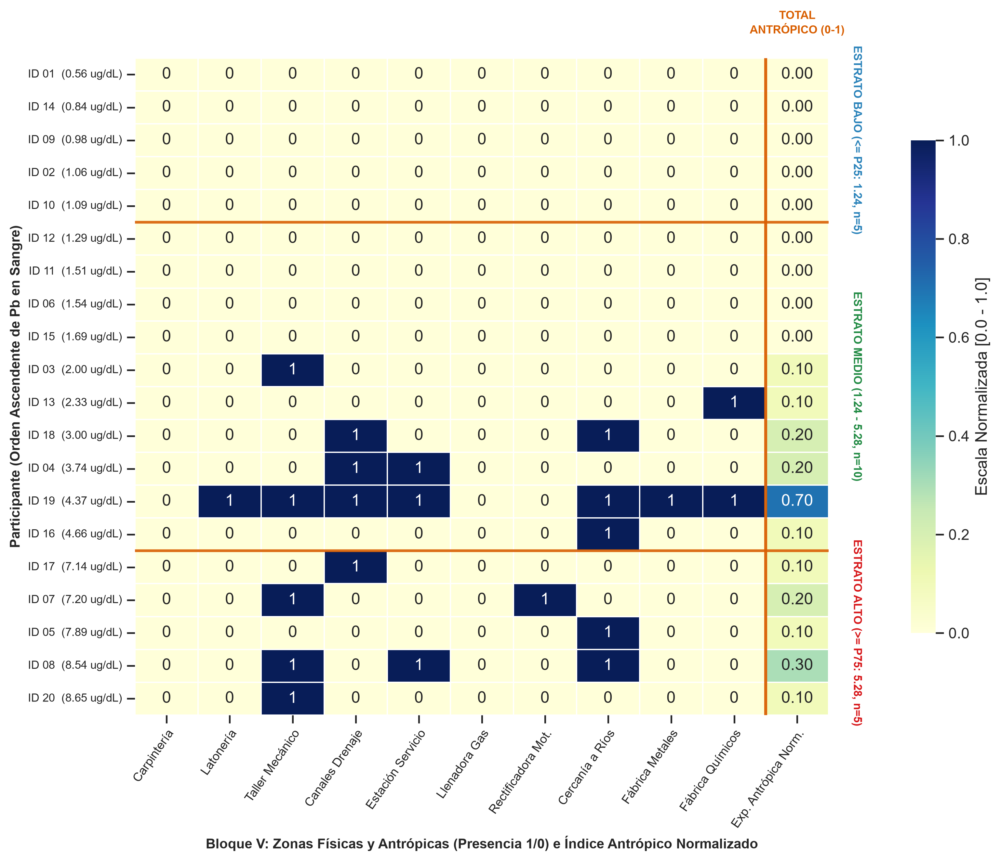

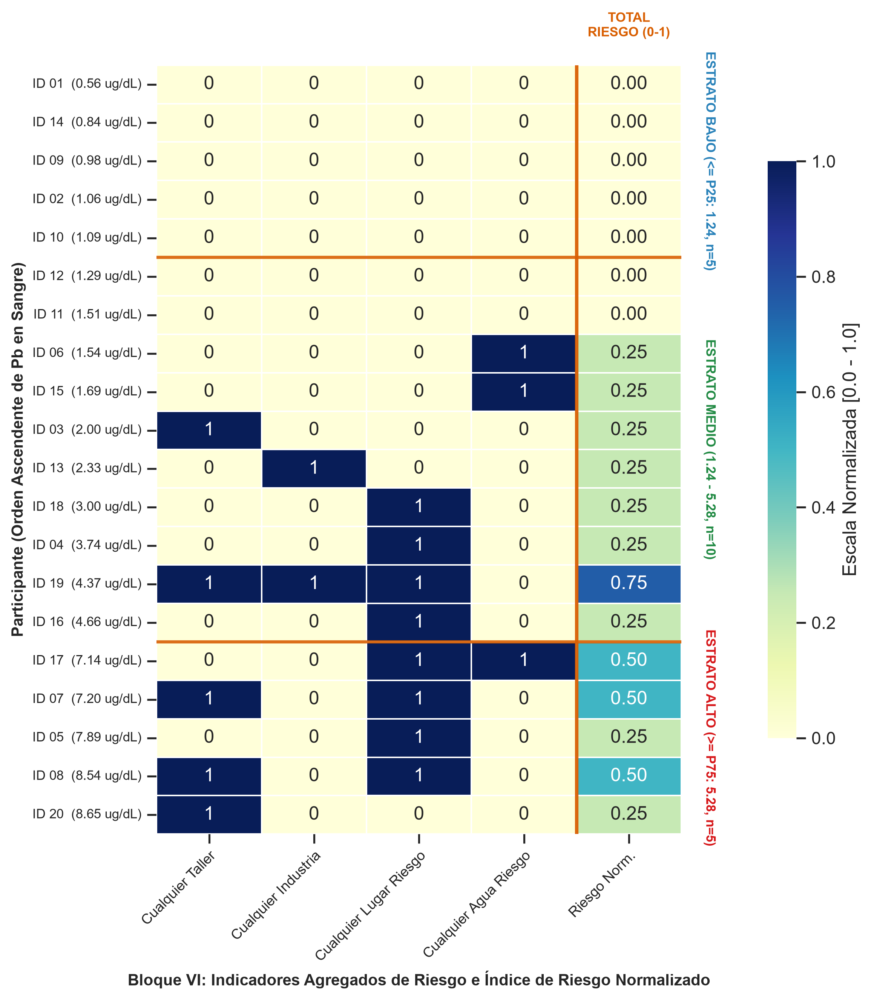

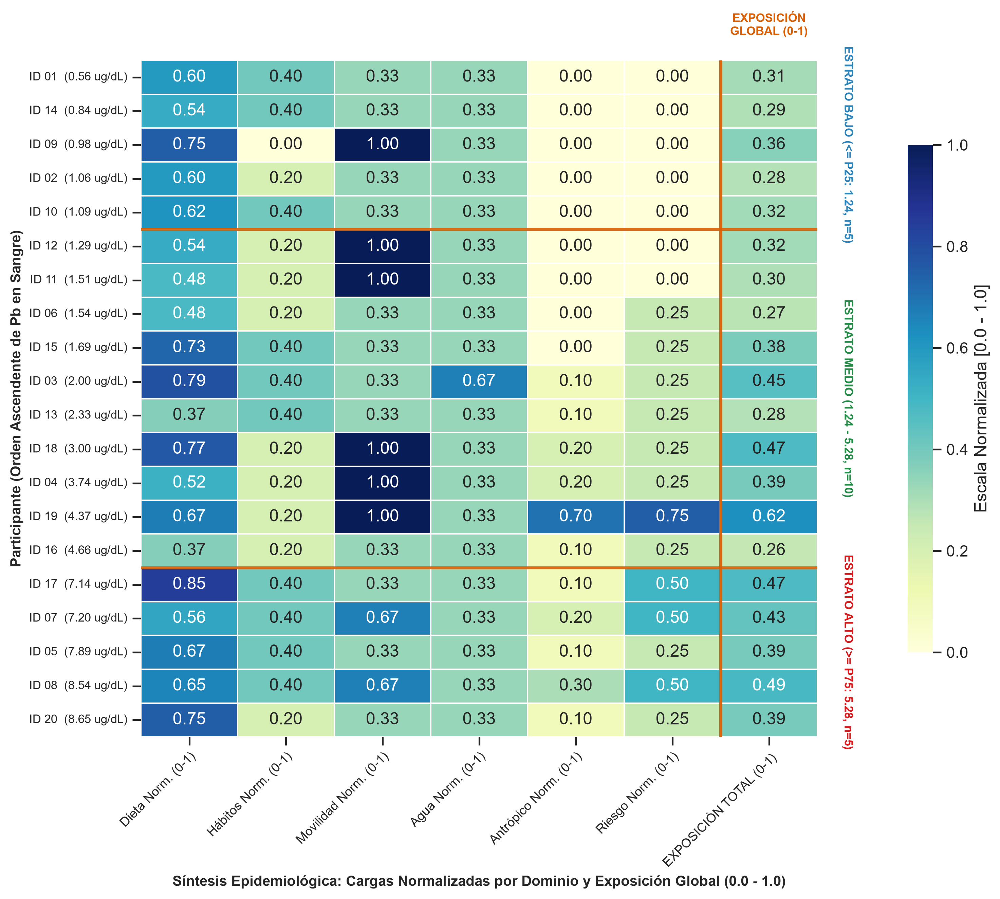

In [25]:
# 2. Opcional: Ejecución automatizada de la suite completa de 7 mapas temáticos
resultados_radiografia = bp.plot_survey_radiography(
    target_metal="Plomo_ug_dL",
    id_col="Muestra_Codificada",
    p25_quantile=0.25,
    p75_quantile=0.75,
    output_dir=salidas_graficos,
    show=True,
    dpi=300,
)